# Exploratory Data Analysis

## Imports

In [1]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import defaultdict

In [2]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
LABEL_COLORS = {
    "PERSON":     "#4A90D9",
    "ITEM":       "#5CB85C",
    "PRICE":      "#F0A500",
    "MULTIPLIER": "#D9534F",
    "O":          "#AAAAAA",
}

## Loading Data

In [3]:
with open('../data/training_data_28k.json', 'r', encoding="utf-8") as f:
    raw = json.load(f)

In [4]:
# normalize, accept either a top-level list or {"data": [...]}
if isinstance(raw, list):
    samples = raw
elif isinstance(raw, dict) and "data" in raw:
    samples = raw["data"]
else:
    raise ValueError("Unexpected JSON structure")

In [5]:
print(f'total samples: {len(samples)}')
print("\nFirst sample:")
print(json.dumps(samples[0], indent=2, ensure_ascii=False))

total samples: 28964

First sample:
{
  "text": "Mohon kesediaannya untuk melunasi tagihan kopi kemarin. Saya lampirkan rinciannya, termasuk biaya surge karena hujan yang cukup mengagetkan.\n- Nurokhmad: jagung rebus (11rebu)\n- Lainnya: sente talas (Rp123k)\nSilakan ditransfer, 3 orang.",
  "entities": [
    {
      "start": 143,
      "end": 152,
      "label": "PERSON",
      "text": "Nurokhmad"
    },
    {
      "start": 154,
      "end": 166,
      "label": "ITEM",
      "text": "jagung rebus"
    },
    {
      "start": 168,
      "end": 174,
      "label": "PRICE",
      "text": "11rebu"
    },
    {
      "start": 187,
      "end": 198,
      "label": "ITEM",
      "text": "sente talas"
    },
    {
      "start": 200,
      "end": 206,
      "label": "PRICE",
      "text": "Rp123k"
    },
    {
      "start": 228,
      "end": 235,
      "label": "MULTIPLIER",
      "text": "3 orang"
    }
  ]
}


### Flatten into two DataFrames

In [6]:
# sample df
# describe how long the text is, how many entities it contains.
# use this to understand the shape of the corpus
df_samples = pd.DataFrame([{
    "id":           i,
    "text":         s["text"],
    "text_len":     len(s["text"]),
    "n_entities":   len(s.get("entities", [])),
    "n_chars":      len(s["text"]),
    "n_lines":      s["text"].count("\n") + 1,
} for i, s in enumerate(samples)])

# entity df
# used to store the entities of a text
# describes every labeled span across all messages
rows = []
for i, s in enumerate(samples):
    for ent in s.get("entities", []):
        span_text = s["text"][ent["start"]:ent["end"]]
        rows.append({
            "sample_id":    i,
            "label":        ent["label"],
            "start":        ent["start"],
            "end":          ent["end"],
            "span_len_chr": ent["end"] - ent["start"],
            "entity_text":  ent.get("text", span_text),
            "raw_span":     span_text,
            "match":        ent.get("text", span_text) == span_text,
        })

df_ents = pd.DataFrame(rows)

print(df_samples.describe())
print(f"\ntotal entities: {len(df_ents)}")
print(df_ents["label"].value_counts())

                 id      text_len    n_entities       n_chars       n_lines
count  28964.000000  28964.000000  28964.000000  28964.000000  28964.000000
mean   14481.500000    227.926633      7.996547    227.926633      3.212781
std     8361.330935    142.397764      4.196893    142.397764      2.970801
min        0.000000     10.000000      0.000000     10.000000      1.000000
25%     7240.750000    122.000000      5.000000    122.000000      1.000000
50%    14481.500000    200.000000      8.000000    200.000000      1.000000
75%    21722.250000    295.000000     10.000000    295.000000      5.000000
max    28963.000000    858.000000     48.000000    858.000000     19.000000

total entities: 231612
label
PRICE         81259
PERSON        79288
ITEM          48391
MULTIPLIER    22674
Name: count, dtype: int64


In [7]:
df_samples.head()

,id,text,text_len,n_entities,n_chars,n_lines
0,0,Mohon kesediaannya untuk melunasi tagihan kopi...,236,6,236,4
1,1,Terlampir rincian pemesanan cafe kemarin. Saya...,240,6,240,4
2,2,"Demi efisiensi waktu, saya sudah buatkan list ...",218,6,218,4
3,3,Rekap bola ikan premium\nTotal: noban setengah...,100,5,100,5
4,4,Billing minyak telon\nAmount: 12k\n7 kepala\nE...,83,5,83,5


In [8]:
df_ents.head(10)

,sample_id,label,start,end,span_len_chr,entity_text,raw_span,match
0,0,PERSON,143,152,9,Nurokhmad,Nurokhmad,True
1,0,ITEM,154,166,12,jagung rebus,jagung rebus,True
2,0,PRICE,168,174,6,11rebu,11rebu,True
3,0,ITEM,187,198,11,sente talas,sente talas,True
4,0,PRICE,200,206,6,Rp123k,Rp123k,True
5,0,MULTIPLIER,228,235,7,3 orang,3 orang,True
6,1,PERSON,136,143,7,Mufiroh,Mufiroh,True
7,1,ITEM,145,166,21,popcorn chicken spicy,popcorn chicken spicy,True
8,1,PRICE,169,174,5,rp31k,rp31k,True
9,1,ITEM,186,197,11,rumput laut,rumput laut,True


## EDA

### Entity Label Distribution

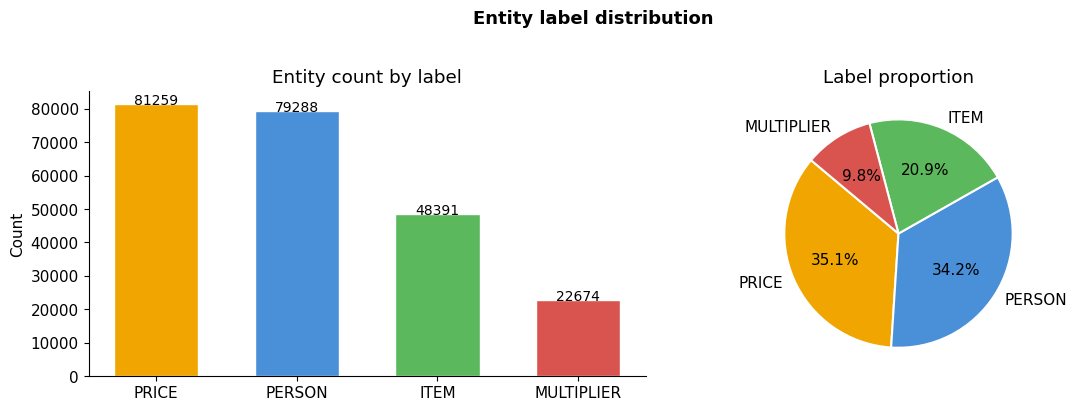

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_counts = df_ents["label"].value_counts()
colors = [LABEL_COLORS.get(l, "#888") for l in label_counts.index]

# plot raw label counts per entity
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor="white", width=0.6)
axes[0].set_title("Entity count by label")
axes[0].set_ylabel("Count")
for i, (label, val) in enumerate(zip(label_counts.index, label_counts.values)):
    axes[0].text(i, val + 0.3, str(val), ha="center", fontsize=10)

# plot the proportion of labels
axes[1].pie(
    label_counts.values,
    labels=label_counts.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[1].set_title("Label proportion")

plt.suptitle("Entity label distribution", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Entities Per Label Distribution

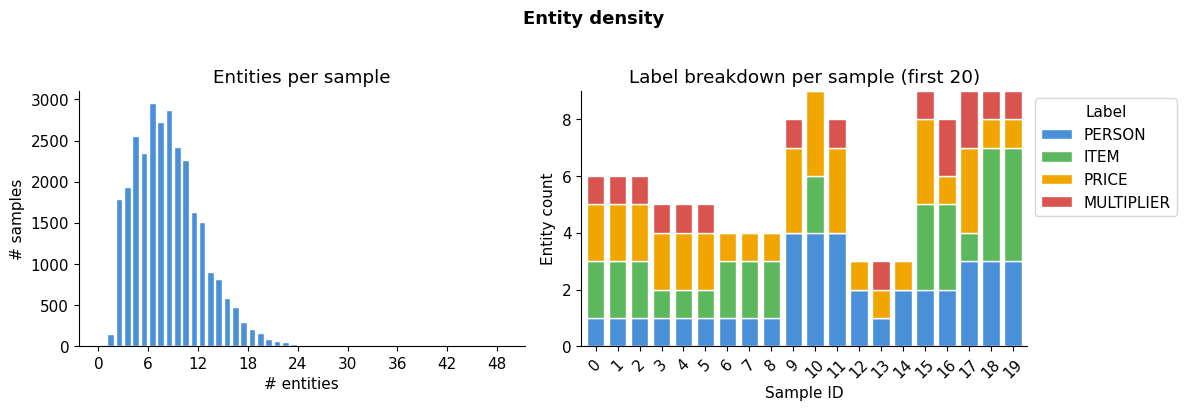

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histogram of entities per sample
axes[0].hist(df_samples["n_entities"], bins=range(0, df_samples["n_entities"].max() + 2),
             color="#4A90D9", edgecolor="white", rwidth=0.8)
axes[0].set_title("Entities per sample")
axes[0].set_xlabel("# entities")
axes[0].set_ylabel("# samples")
axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# stacked bar showing label breakdown per sample (top 20 samples)
pivot = df_ents.groupby(["sample_id", "label"]).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=["PERSON", "ITEM", "PRICE", "MULTIPLIER"], fill_value=0)
pivot.head(20).plot(
    kind="bar", stacked=True, ax=axes[1],
    color=[LABEL_COLORS[c] for c in pivot.columns],
    edgecolor="white", width=0.8
)
axes[1].set_title("Label breakdown per sample (first 20)")
axes[1].set_xlabel("Sample ID")
axes[1].set_ylabel("Entity count")
axes[1].legend(title="Label", bbox_to_anchor=(1, 1))
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Entity density", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Span Character Length By Label

C:\Users\ASUS\AppData\Local\Temp\ipykernel_43200\1457558122.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_by_label, labels=order, patch_artist=True, widths=0.5,


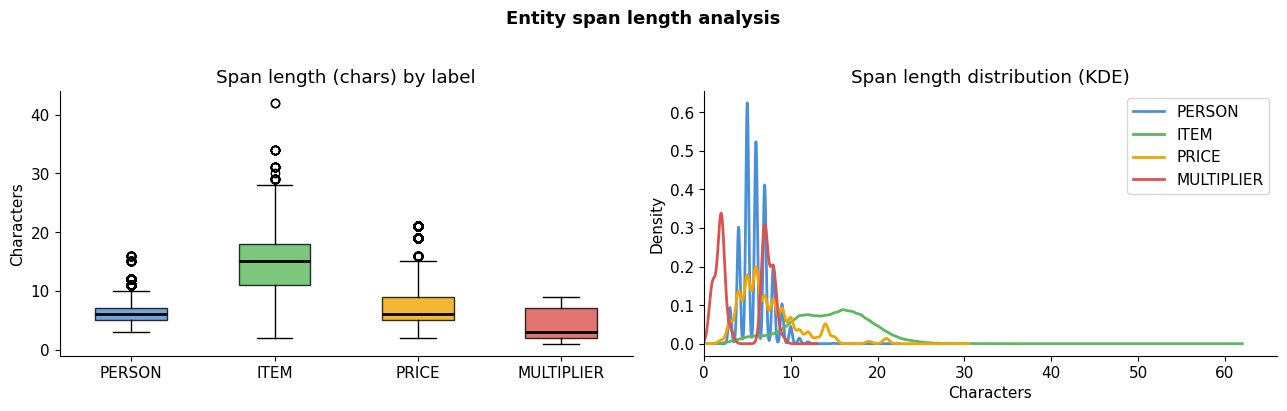

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# box plot
order = ["PERSON", "ITEM", "PRICE", "MULTIPLIER"]
data_by_label = [df_ents[df_ents["label"] == l]["span_len_chr"].values for l in order]

bp = axes[0].boxplot(data_by_label, labels=order, patch_artist=True, widths=0.5,
                     medianprops={"color": "black", "linewidth": 2})
for patch, label in zip(bp["boxes"], order):
    patch.set_facecolor(LABEL_COLORS[label])
    patch.set_alpha(0.8)
axes[0].set_title("Span length (chars) by label")
axes[0].set_ylabel("Characters")

# KDE per label
for label in order:
    vals = df_ents[df_ents["label"] == label]["span_len_chr"]
    if len(vals) > 1:
        vals.plot.kde(ax=axes[1], label=label, color=LABEL_COLORS[label], linewidth=2)
axes[1].set_title("Span length distribution (KDE)")
axes[1].set_xlabel("Characters")
axes[1].legend()
axes[1].set_xlim(left=0)

plt.suptitle("Entity span length analysis", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Text (sample) length distribution

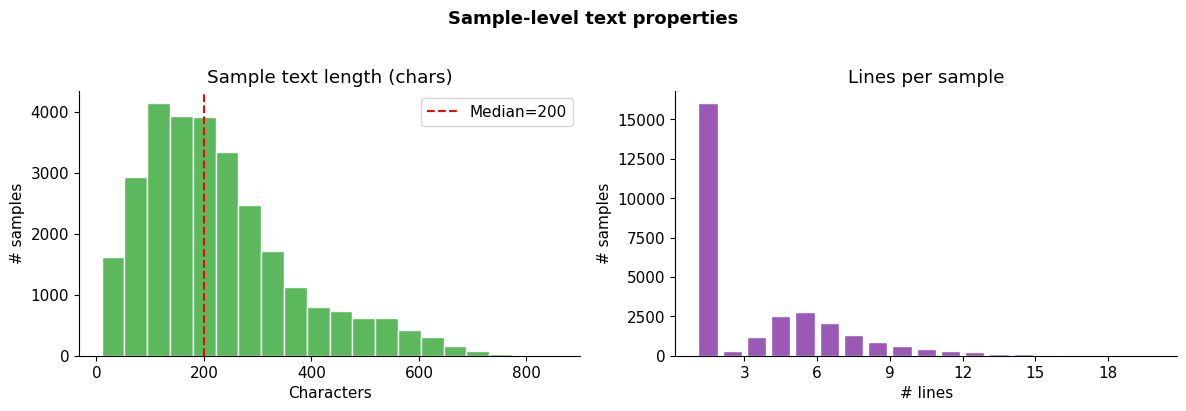

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# plot sample text length (chars)
axes[0].hist(df_samples["text_len"], bins=20, color="#5CB85C", edgecolor="white")
axes[0].set_title("Sample text length (chars)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("# samples")
axes[0].axvline(df_samples["text_len"].median(), color="red", linestyle="--", label=f'Median={df_samples["text_len"].median():.0f}')
axes[0].legend()

# lines per sample
axes[1].hist(df_samples["n_lines"], bins=range(1, df_samples["n_lines"].max() + 2),
             color="#9B59B6", edgecolor="white", rwidth=0.8)
axes[1].set_title("Lines per sample")
axes[1].set_xlabel("# lines")
axes[1].set_ylabel("# samples")
axes[1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.suptitle("Sample-level text properties", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Top Entity Surface Forms Per Label

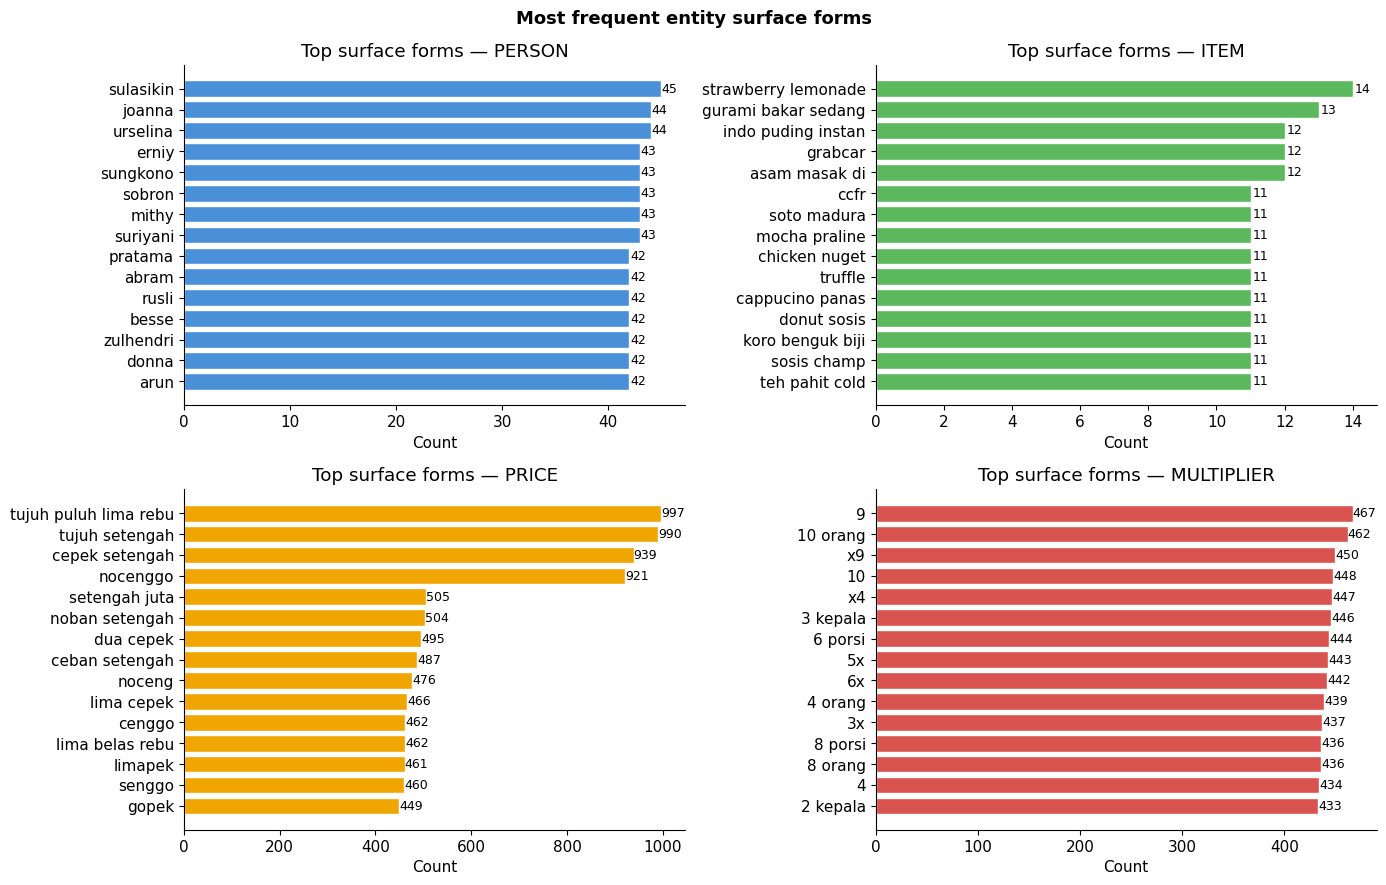

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, label in zip(axes, ["PERSON", "ITEM", "PRICE", "MULTIPLIER"]):
    subset = df_ents[df_ents["label"] == label]["entity_text"].str.lower().str.strip()
    counts = subset.value_counts().head(15)
    ax.barh(counts.index[::-1], counts.values[::-1],
            color=LABEL_COLORS[label], edgecolor="white")
    ax.set_title(f"Top surface forms — {label}")
    ax.set_xlabel("Count")
    for i, (val, name) in enumerate(zip(counts.values[::-1], counts.index[::-1])):
        ax.text(val + 0.05, i, str(val), va="center", fontsize=9)

plt.suptitle("Most frequent entity surface forms", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### PRICE Noise Pattern Taxonomy

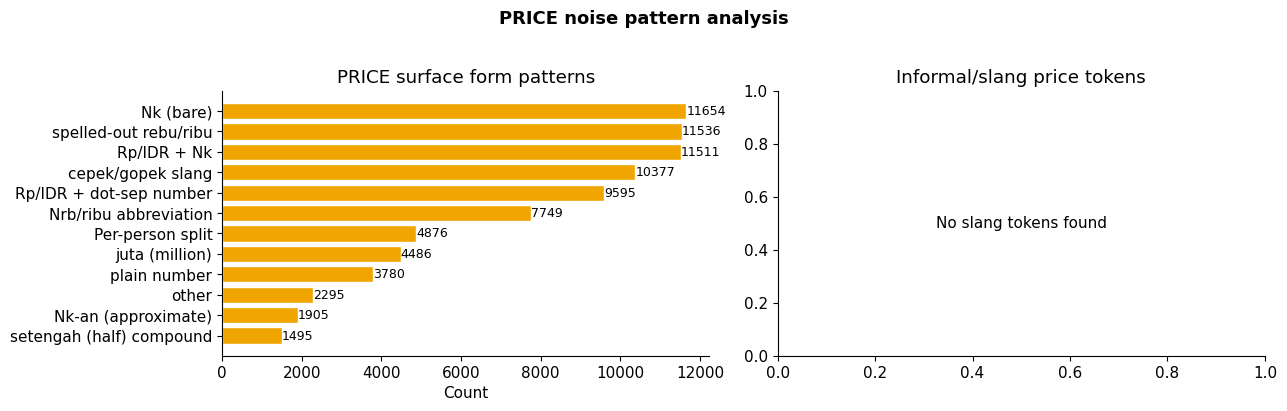


All PRICE patterns with examples:
  Nk (bare)                      → ['84 k', '12k', '±11k', '181K', '37 k']
  Nk-an (approximate)            → ['461k-an', '39k-an', '43k-an', '194k-an', '69k-an']
  Nrb/ribu abbreviation          → ['11rebu', '14ribu', '276rb', '87RB', '57ribu']
  Per-person split               → ['30k per orang', 'Rp20k/orang', '30ribu/orang', '25k perorang', '10k/org']
  Rp/IDR + Nk                    → ['Rp123k', 'rp31k', 'Rp17k', 'Rp 408k', 'RP15k']
  Rp/IDR + dot-sep number        → ['IDR 244.000', 'IDR 16.000', 'IDR 63.000', 'IDR 60.000', 'rp13.000']
  cepek/gopek slang              → ['noban setengah', 'noban', 'satu ceban', 'setengah cepek', 'ceban setengah']
  juta (million)                 → ['1.8 jt', '2.2 J', '2.2juta', 'Rp3jt', 'Rp 4 juta']
  other                          → ['18.000,-', '145.000,-', '100.000,-', '25.000,-', '8.000,-']
  plain number                   → ['238.000', '248.000', '282.000,00', '211.000', '118.000']
  setengah (half) compound 

In [14]:
REBU_PATTERN = re.compile(r'(satu|dua|tiga|empat|lima|enam|tujuh|delapan|sembilan|'
                           r'sepuluh|sebelas|dua belas|lima belas|dua puluh[\w\s]*|'
                           r'tiga puluh[\w\s]*|[\w\s]+)\s+(rebu|ribu|rb|rbu)', re.I)
JUTA_PATTERN = re.compile(r'([\d.,]+\s*j(uta|t)?|setengah juta|\d+\.\d+\s*jt)', re.I)

def classify_price(text):
    t = text.strip().lower()
    
    CEPEK_WORDS = {"cepek", "gopek", "ceban", "noban", "senggo", "cenggo",
                   "nocenggo", "noceng", "limapek", "dua ceng", "seceng",
                   "seceban", "secepek", "goceng", "gocen", "gocap", "saceng"}

    if any(w in t for w in CEPEK_WORDS):           return "cepek/gopek slang"
    if "setengah" in t or "tengah" in t:           return "setengah (half) compound"
    if JUTA_PATTERN.search(t):                     return "juta (million)"
    if REBU_PATTERN.search(t):                     return "spelled-out rebu/ribu"
    
    # support for per-person splits (with or without Rp, with slash or "per")
    if re.search(r'(?:/|per\s*)(orang|kepala|org)', t): return "Per-person split"
    
    # allow optional approximate symbols at the start of formats
    if re.fullmatch(r'[~±]?\s*(rp|idr)\s*[\d.]+,?-?', t):  return "Rp/IDR + dot-sep number"
    if re.fullmatch(r'[~±]?\s*(rp|idr)\s*[\d]+\s*k', t):   return "Rp/IDR + Nk"
    if re.fullmatch(r'[~±]?\s*[\d.,]+\s*k-an', t):         return "Nk-an (approximate)"
    if re.fullmatch(r'[~±]?\s*[\d.,]+\s*k', t):            return "Nk (bare)"
    
    # catch rb, ribu, rebu, and the "an" suffix
    if re.fullmatch(r'[~±]?\s*[\d.,]+\s*(rb|ribu|rebu)(?:\s*an)?', t): return "Nrb/ribu abbreviation"
    if re.fullmatch(r'[~±]?\s*[\d.,]+(,00)?', t):          return "plain number"
    
    return "other"

prices = df_ents[df_ents["label"] == "PRICE"].copy()
prices["pattern"] = prices["entity_text"].apply(classify_price)

pattern_counts = prices["pattern"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].barh(pattern_counts.index[::-1], pattern_counts.values[::-1],
             color="#F0A500", edgecolor="white")
axes[0].set_title("PRICE surface form patterns")
axes[0].set_xlabel("Count")
for i, val in enumerate(pattern_counts.values[::-1]):
    axes[0].text(val + 0.05, i, str(val), va="center", fontsize=9)

# Show all slang/informal prices explicitly
slang = prices[prices["pattern"] == "informal/slang"]["entity_text"].value_counts().head(20)

if not slang.empty:
    axes[1].barh(slang.index[::-1], slang.values[::-1], color="#D9534F", edgecolor="white")
    axes[1].set_title("Top 20 Informal/slang price tokens")
    axes[1].set_xlabel("Count")
else:
    axes[1].text(0.5, 0.5, "No slang tokens found", ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_title("Informal/slang price tokens")

plt.suptitle("PRICE noise pattern analysis", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nAll PRICE patterns with examples:")
for pattern, group in prices.groupby("pattern"):
    examples = group["entity_text"].unique()[:5].tolist()
    print(f"  {pattern:30s} → {examples}")

### Special character inventory in entity spans

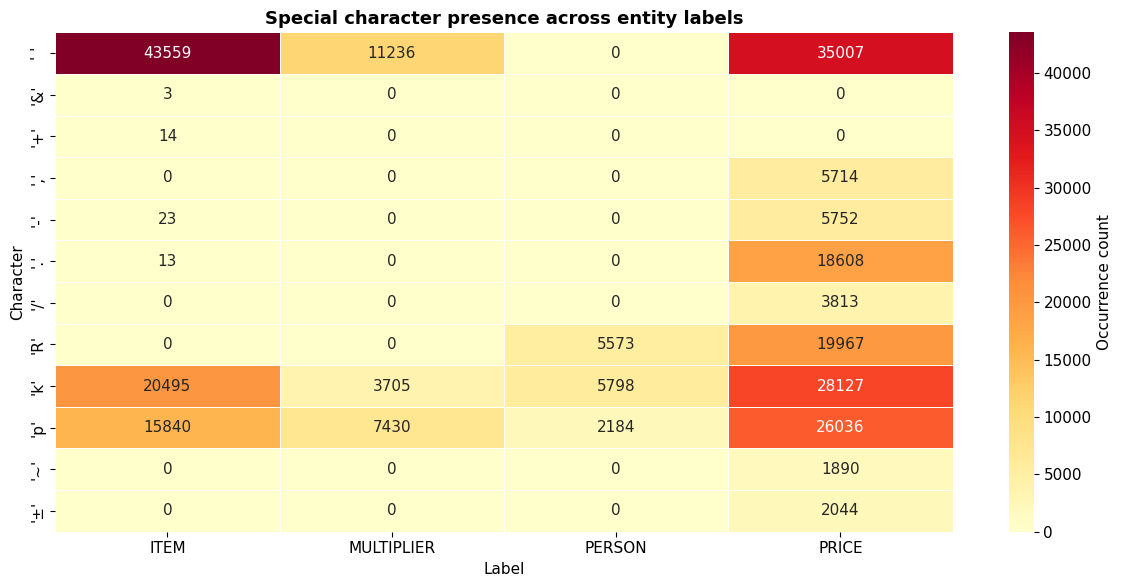

In [15]:
SPECIAL_CHARS = list("Rp.,k/-±~()[]_?")

char_label_counts = defaultdict(lambda: defaultdict(int))

for _, row in df_ents.iterrows():
    for ch in set(row["entity_text"]):
        if ch in SPECIAL_CHARS or not ch.isalnum():
            char_label_counts[ch][row["label"]] += 1

rows_ch = []
for ch, label_dict in char_label_counts.items():
    for label, count in label_dict.items():
        rows_ch.append({"char": repr(ch), "label": label, "count": count})

df_chars = pd.DataFrame(rows_ch)

if not df_chars.empty:
    pivot_ch = df_chars.pivot_table(index="char", columns="label", values="count", fill_value=0).astype(int)
    
    fig, ax = plt.subplots(figsize=(12, max(4, len(pivot_ch) * 0.5)))
    sns.heatmap(pivot_ch, annot=True, fmt="d", cmap="YlOrRd",
                linewidths=0.5, ax=ax, cbar_kws={"label": "Occurrence count"})
    ax.set_title("Special character presence across entity labels", fontsize=13, fontweight="bold")
    ax.set_xlabel("Label")
    ax.set_ylabel("Character")
    plt.tight_layout()
    plt.show()

### Span Offset Alignment Check

Total entities   : 231612
Offset mismatches: 169 (0.1%)

 sample_id  label           entity_text              raw_span
      3462  PRICE       Rp 15.000/orang       0/orang terus b
      3462  PRICE              Rp90.000              t parkir
      3462 PERSON               Tresyne               ore gue
      3463  PRICE           Rp20k/orang            per orang.
      3463  PRICE                 487 K                 ua bu
      3464  PRICE                14rebu                 emua.
      3464  PRICE        cepek setengah        tengah buat pl
      4134  PRICE                 Rp31k                 k, te
      4134  PRICE             389.000,-              -. Terus
      4134  PRICE             186 rb an             n per ora
      4134 PERSON            Suherianto             to please
      4134  PRICE                 53 rb                  biar
      4135  PRICE                68ribu                bu, ya
      4135  PRICE                 2.5jt                  erus
      4135  P

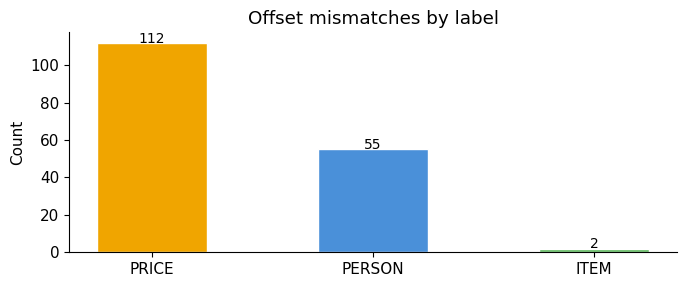

In [16]:
# checks whether entity["text"] matches what's actually at [start:end] in the raw string.
# mismatches reveal bracket/suffix noise you need to handle before BIO conversion.
mismatches = df_ents[~df_ents["match"]].copy()
mismatches["raw_span"] = mismatches["raw_span"].str.strip()

print(f"Total entities   : {len(df_ents)}")
print(f"Offset mismatches: {len(mismatches)} ({100*len(mismatches)/len(df_ents):.1f}%)\n")

if not mismatches.empty:
    print(mismatches[["sample_id", "label", "entity_text", "raw_span"]].to_string(index=False))

    fig, ax = plt.subplots(figsize=(7, 3))
    mismatch_by_label = mismatches["label"].value_counts()
    ax.bar(mismatch_by_label.index, mismatch_by_label.values,
           color=[LABEL_COLORS.get(l, "#888") for l in mismatch_by_label.index],
           edgecolor="white", width=0.5)
    ax.set_title("Offset mismatches by label")
    ax.set_ylabel("Count")
    for i, val in enumerate(mismatch_by_label.values):
        ax.text(i, val + 0.1, str(val), ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("All spans align perfectly — no offset issues.")

#### Fix Offsets

In [17]:
# helper function to find the correct character offset for a misaligned entity
# returns (new_start, new_end) if found, or None if unresolvable
def fix_offset(sample_text, entity):
    target = entity["text"]
    
    # search in a window around the originally annotated position
    search_start = max(0, entity["start"] - 30)
    search_end   = min(len(sample_text), entity["end"] + 30)
    window       = sample_text[search_start:search_end]
    
    idx = window.find(target)
    if idx != -1:
        new_start = search_start + idx
        new_end   = new_start + len(target)
        return new_start, new_end
    
    # try case-insensitive fallback
    idx = window.lower().find(target.lower())
    if idx != -1:
        new_start = search_start + idx
        new_end   = new_start + len(target)
        return new_start, new_end
    
    return None  # couldn't resolve

In [18]:
fixed_samples  = []   # samples with corrections applied
unfixable      = []   # entities we couldn't resolve — need manual review

for i, sample in enumerate(samples):
    new_entities = []
    
    for ent in sample.get("entities", []):
        raw_span = sample["text"][ent["start"]:ent["end"]]
        
        # check if aligned
        if raw_span == ent.get("text", raw_span):
            new_entities.append(ent)
            continue
        
        # try fix
        result = fix_offset(sample["text"], ent)
        
        if result is not None:
            new_start, new_end = result
            fixed_ent = {
                **ent,
                "start": new_start,
                "end":   new_end,
            }
            new_entities.append(fixed_ent)
        else:
            unfixable.append({
                "sample_id":   i,
                "label":       ent["label"],
                "entity_text": ent.get("entity_text", ""),
                "bad_start":   ent["start"],
                "bad_end":     ent["end"],
                "raw_span":    raw_span,
            })
            # still keep the original so the sample isn't silenty dropped
            new_entities.append(ent)
    
    fixed_samples.append({**sample, "entities": new_entities})

print(f"Unfixable entities : {len(unfixable)}")
print(f"Samples processed  : {len(fixed_samples)}")

Unfixable entities : 0
Samples processed  : 28964


In [19]:
df_unfixable = pd.DataFrame(unfixable)

if not df_unfixable.empty:
    print("Unfixable breakdown by label:")
    print(df_unfixable["label"].value_counts())
    print()
    print(df_unfixable.to_string(index=False))
else:
    print("All mismatches resolved.")

All mismatches resolved.


In [20]:
output_path = "../data/dataset_fixed_28k.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(fixed_samples, f, ensure_ascii=False, indent=2)

print(f"Saved cleaned dataset → {output_path}")

Saved cleaned dataset → ../data/dataset_fixed_28k.json


### Summary stats table

In [21]:
summary = df_ents.groupby("label").agg(
    count=("entity_text", "count"),
    unique_forms=("entity_text", "nunique"),
    avg_span_len=("span_len_chr", "mean"),
    max_span_len=("span_len_chr", "max"),
    min_span_len=("span_len_chr", "min"),
).round(1)

summary["samples_with_label"] = df_ents.groupby("label")["sample_id"].nunique()
summary["avg_per_sample"] = (summary["count"] / len(df_samples)).round(2)

print(summary.to_string())

            count  unique_forms  avg_span_len  max_span_len  min_span_len  samples_with_label  avg_per_sample
label                                                                                                        
ITEM        48391         18724          14.4            42             2               22826            1.67
MULTIPLIER  22674            54           4.6             9             1               19042            0.78
PERSON      79288          3076           6.0            16             3               26428            2.74
PRICE       81259         10621           7.4            21             2               25534            2.81
